# Занятие 1. Подготовка данных

Date: 07.05.2026\
Author: *Andrey Zakharov*\
Extended by: *Matvey Bakshuk, FCS HSE*

Формула итоговой оценки:

$$\text{HW}_1\times0.25+\text{HW}_2\times0.25+\text{HW}_3\times0.25+\text{HW}_4\times0.25$$

Обычно подготовка данных к анализу (предобработка) включает следующие задачи:
- загрузка и осмотр данных
- изменение формата (reshape)
- объединение таблиц
- обработка дублирующихся наблюдений
- обработка пропущенных значений
- отбор и фильтрация данных
- переименование и перекодирование переменных

Не все эти задачи встречаются в каждом проекте, и их порядок может варьироваться. Иногда требуются дополнительные шаги (например, снижение размерности), которые мы рассмотрим позже. Всё зависит от исследовательского вопроса и данных.

> **Ключевая идея:** подготовка данных — не разовый шаг. На практике вы многократно итерируете между осмотром и очисткой по мере того, как лучше узнаёте данные.

Сегодня мы работаем с данными [Всемирного доклада о счастье](https://worldhappiness.report/data/). Исследование проводится ежегодно в партнёрстве Gallup, Оксфордского центра исследований благополучия, Сети решений устойчивого развития ООН и редакционного совета WHR. Цель — измерить уровень счастья в разных странах мира.

![](https://as2.ftcdn.net/v2/jpg/01/80/67/87/1000_F_180678712_IMJ6IMyrZEqLrjKSEwMo0edBO49DB29J.jpg)

### 1. Загрузка и осмотр данных

Первый шаг в любом проекте: **загрузить данные и понять их структуру**, прежде чем что-либо менять. Нужно знать, сколько наблюдений, какие переменные присутствуют, каковы их типы и нет ли очевидных проблем.

In [82]:
# pip install np
# pip install pd
# pip install seaborn

In [83]:
import numpy as np
import pandas as pd

In [84]:
df = pd.read_excel('DataForTable2.1WHR2023.xls')

**Проверяем размер таблицы и типы переменных.**

`df.shape` возвращает `(строки, столбцы)` — самая базовая проверка. `df.dtypes` показывает определённый тип каждого столбца: `int64`, `float64`, `object` (текст) и т.д. `df.info()` объединяет оба: дополнительно показывает количество непустых значений в каждом столбце, что даёт ранний сигнал о пропусках.

In [85]:
# Ваш код здесь
df.shape

(2199, 11)

Видим, какие переменные присутствуют в датасете. Всегда читайте **словарь данных** (или описания столбцов), прежде чем продолжать — нельзя чистить или преобразовывать переменную, смысл которой вам непонятен.

In [86]:
df.columns.to_list()

['Country name',
 'year',
 'Life Ladder',
 'Log GDP per capita',
 'Social support',
 'Healthy life expectancy at birth',
 'Freedom to make life choices',
 'Generosity',
 'Perceptions of corruption',
 'Positive affect',
 'Negative affect']

Данные включают страны-участницы исследования, годы опросов, логарифм ВВП на душу населения, ожидаемую продолжительность жизни. `Life Ladder` — это индекс счастья. Респондентов просят «представить лестницу, где 10 — наилучшая возможная жизнь, а 0 — наихудшая, и оценить свою нынешнюю жизнь по этой шкале». Также присутствуют другие индексы, связанные со счастьем.

Все данные агрегированы на уровне стран.

Посмотрим на типы переменных.

`Life Ladder` — наша основная **зависимая переменная** (индекс счастья). Она основана на вопросе Кантрила: респондентов просят представить лестницу, где 0 — худшая возможная жизнь, а 10 — лучшая, и указать своё место на ней. Это **субъективная** мера — она отражает воспринимаемое благополучие, а не объективные условия жизни.

In [87]:
df.dtypes

Country name                         object
year                                  int64
Life Ladder                         float64
Log GDP per capita                  float64
Social support                      float64
Healthy life expectancy at birth    float64
Freedom to make life choices        float64
Generosity                          float64
Perceptions of corruption           float64
Positive affect                     float64
Negative affect                     float64
dtype: object

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2199 non-null   object 
 1   year                              2199 non-null   int64  
 2   Life Ladder                       2199 non-null   float64
 3   Log GDP per capita                2179 non-null   float64
 4   Social support                    2186 non-null   float64
 5   Healthy life expectancy at birth  2145 non-null   float64
 6   Freedom to make life choices      2166 non-null   float64
 7   Generosity                        2126 non-null   float64
 8   Perceptions of corruption         2083 non-null   float64
 9   Positive affect                   2175 non-null   float64
 10  Negative affect                   2183 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 189.1+ KB


**Выводим первые 10 наблюдений**, чтобы визуально убедиться, что данные загружены правильно: имена столбцов верны, нет лишних строк заголовка, значения выглядят правдоподобно.

In [89]:
# Ваш код здесь
df.head(10)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,0.414297,0.258195
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,0.481421,0.237092
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,0.516907,0.275324
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,0.479835,0.267175
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,0.613513,0.267919
5,Afghanistan,2013,3.572100,7.680333,0.483552,52.000000,0.577955,0.062666,0.823204,0.547417,0.273328
6,Afghanistan,2014,3.130896,7.670638,0.525568,52.299999,0.508514,0.105755,0.871242,0.491641,0.374861
7,Afghanistan,2015,3.982855,7.653833,0.528597,52.599998,0.388928,0.081652,0.880638,0.491410,0.339276
8,Afghanistan,2016,4.220169,7.650370,0.559072,52.924999,0.522566,0.043916,0.793246,0.501409,0.348332
9,Afghanistan,2017,2.661718,7.647830,0.490880,53.250000,0.427011,-0.119410,0.954393,0.435270,0.371326


**Описательная статистика числовых переменных.**

`df.describe()` returns count, mean, std, min, three quartiles (25%, 50%, 75%), and max. Even at this early stage you can spot distributional issues:
- If **mean < median (50%)** → negative skew (long left tail)
- If **mean > median** → positive skew (long right tail)
- If **std is very large** relative to mean → potential outliers
- If **min or max looks impossible** (e.g. negative age) → data entry error

We transpose (`.T`) and round (`.round(2)`) for readability.

In [90]:
# Ваш код здесь
df.describe(include = np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,2199.0,2014.16,4.72,2005.00,2010.00,2014.00,2018.00,2022.00
Life Ladder,2199.0,5.48,1.13,1.28,4.65,5.43,6.31,8.02
Log GDP per capita,2179.0,9.39,1.15,5.53,8.50,9.50,10.37,11.66
Social support,2186.0,0.81,0.12,0.23,0.75,0.84,0.90,0.99
Healthy life expectancy at birth,2145.0,63.29,6.90,6.72,59.12,65.05,68.50,74.47
Freedom to make life choices,2166.0,0.75,0.14,0.26,0.66,0.77,0.86,0.99
Generosity,2126.0,0.00,0.16,-0.34,-0.11,-0.02,0.09,0.70
Perceptions of corruption,2083.0,0.75,0.19,0.04,0.69,0.80,0.87,0.98
Positive affect,2175.0,0.65,0.11,0.18,0.57,0.66,0.74,0.88
Negative affect,2183.0,0.27,0.09,0.08,0.21,0.26,0.32,0.70


На следующем занятии мы будем строить графики, но уже сейчас можно заметить, что некоторые переменные имеют скошенное распределение. Среднее < медианы означает отрицательный скос, а среднее > медианы — положительный. Возможно, нам потребуется преобразовать шкалы позже, чтобы приблизить распределение к нормальному.

Identifying skewed distributions at this stage tells you which variables will likely need **nonlinear transformation** later (see §9).

**Описательная статистика текстовых (object) переменных.**

Для нечисловых столбцов `describe()` возвращает: count, количество уникальных значений (`unique`), наиболее частое значение (`top`) и его частоту (`freq`). Это быстро показывает, является ли текстовый столбец действительно категориальным (мало уникальных значений) или по сути идентификатором (много уникальных значений).ree-text field (many unique values).

In [91]:
# Ваш код здесь
df.describe(include = object).T

,count,unique,top,freq
Country name,2199,165,Lebanon,17


Вывод `describe()` для `Country name` не очень информативен — посмотрим напрямую на уникальные значения и их количество.

In [92]:
# Ваш код здесь
df['Country name'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain',
       'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)',
       'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Estonia', 'Eswatini', 'Ethiopia', 'Finland',
       'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'Honduras',
       'Hong Kong S.A.R. of China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Ivory Coast', 'Jamaica', 'Japan', 

In [93]:
print(f"{df['Country name'].nunique()} countries in general")   #same number as in describe() output

165 countries in general


**Таблица частот** — сколько наблюдений на каждую страну.

Поскольку данные **продольные** (одни и те же страны опрашиваются несколько лет подряд), ожидается несколько строк на страну. У стран с меньшим числом записей, чем ожидалось, отсутствуют данные за некоторые годы.

In [94]:
# Ваш код здесь
df['Country name'].value_counts().sort_index()

Country name
Afghanistan    14
Albania        15
Algeria        10
Angola          4
Argentina      17
               ..
Venezuela      17
Vietnam        17
Yemen          12
Zambia         15
Zimbabwe       17
Name: count, Length: 165, dtype: int64

Теперь видно количество наблюдений для каждой страны.

Из описательной статистики и таблицы частот также можно заметить наличие пропущенных значений. Разберёмся с ними позже.

Note that `value_counts()` by default sorts by frequency (most common first). We use `.sort_index()` to sort alphabetically instead — easier to find a specific country.

#### Вспомним, как используются индексы в pandas

pandas поддерживает две системы индексирования:
- **`iloc`** — позиционное индексирование по целым числам. `df.iloc[0, 3]` означает строку 0, столбец 3.
- **`loc`** — индексирование по меткам. `df.loc[0, 'year']` означает строку с меткой 0, столбец с именем 'year'.

Ключевое отличие: `iloc` slices **exclude** the endpoint (like Python lists); `loc` slices **include** the endpoint.

In [95]:
# Ваш код здесь
df.iloc[:10,3:-3]

,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity
0,7.350416,0.450662,50.500000,0.718114,0.167652
1,7.508646,0.552308,50.799999,0.678896,0.190809
2,7.613900,0.539075,51.099998,0.600127,0.121316
3,7.581259,0.521104,51.400002,0.495901,0.163571
4,7.660506,0.520637,51.700001,0.530935,0.237588
5,7.680333,0.483552,52.000000,0.577955,0.062666
6,7.670638,0.525568,52.299999,0.508514,0.105755
7,7.653833,0.528597,52.599998,0.388928,0.081652
8,7.650370,0.559072,52.924999,0.522566,0.043916
9,7.647830,0.490880,53.250000,0.427011,-0.119410


In [96]:
# Ваш код здесь
df.loc[:10,['Country name', 'year', 'Life Ladder']]

,Country name,year,Life Ladder
0,Afghanistan,2008,3.723590
1,Afghanistan,2009,4.401778
2,Afghanistan,2010,4.758381
3,Afghanistan,2011,3.831719
4,Afghanistan,2012,3.782938
5,Afghanistan,2013,3.572100
6,Afghanistan,2014,3.130896
7,Afghanistan,2015,3.982855
8,Afghanistan,2016,4.220169
9,Afghanistan,2017,2.661718


### 2. Изменение формата данных

Данные могут храниться в двух основных форматах:

| Формат | Структура | Лучше для |
|--------|-----------|----------|
| **Длинный (long)** | Одна строка на наблюдение (страна × год) | Статистические модели, операции groupby |
| **Широкий (wide)** | Одна строка на объект (страну), один столбец на момент времени | Визуализация временных рядов, матрицы корреляций |

Наши данные — в **длинном формате**: единица наблюдения — страна в конкретный год. Для некоторых целей (например, просмотра динамики счастья по стране) может потребоваться преобразование.

#### Pivot (длинный → широкий)

`pivot()` принимает три аргумента:
- `index` — что становится идентификатором строки
- `columns` — что становится заголовками новых столбцов
- `values` — какая переменная заполняет ячейки

![](https://tavareshugo.github.io/r-intro-tidyverse-gapminder/fig/07-data_shapes.png)

In [97]:
df_wide = df.pivot(index = 'Country name', columns = 'year', values = 'Life Ladder')
df_wide.head()

year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Country name,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,3.723590,4.401778,4.758381,3.831719,3.782938,3.572100,3.130896,3.982855,4.220169,2.661718,2.694303,2.375092,NaN,2.436034,1.281271
Albania,NaN,NaN,4.634252,NaN,5.485470,5.268937,5.867422,5.510124,4.550648,4.813763,4.606651,4.511101,4.639548,5.004403,4.995318,5.364910,5.255482,5.212213
Algeria,NaN,NaN,NaN,NaN,NaN,5.463567,5.317194,5.604596,NaN,6.354898,NaN,5.340854,5.248912,5.043086,4.744627,5.437755,5.217018,NaN
Angola,NaN,NaN,NaN,NaN,NaN,NaN,5.589001,4.360250,3.937107,3.794838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,NaN,6.312925,6.073158,5.961034,6.424133,6.441067,6.775805,6.468387,6.582260,6.671114,6.697131,6.427221,6.039330,5.792797,6.085561,5.900567,5.908279,6.260993


Видно динамику счастья по странам. У Афганистана пик был около 2010 года, после чего наблюдается снижение. Некоторые страны (Албания, Аргентина) показывают относительно стабильные значения.

Широкий формат удобен для **визуального осмотра**, но большинство алгоритмов ML и статистических моделей ожидают длинный формат. Помните об этом при переключении между видами анализа.

Мы вернёмся к изменению формата на следующей лекции при создании визуализаций.

#### Unpivot (широкий → длинный формат)

`pd.melt()` — обратная операция к `pivot()`. Она «плавит» заголовки столбцов обратно в столбец переменных.

Ключевые параметры:
- `ignore_index=False` — сохранить исходный индекс (здесь: `Country name`)
- `value_name` — название столбца, который будет хранить значения

После melt сортируем по стране и году, чтобы восстановить исходный порядок строк.

In [98]:
df_long = pd.melt(df_wide, ignore_index = False, value_name = 'Life Ladder').sort_values(['Country name', 'year'])
df_long

,year,Life Ladder
Country name,,
Afghanistan,2005,NaN
Afghanistan,2006,NaN
Afghanistan,2007,NaN
Afghanistan,2008,3.723590
Afghanistan,2009,4.401778
...,...,...
Zimbabwe,2018,3.616480
Zimbabwe,2019,2.693523
Zimbabwe,2020,3.159802


### 3. Объединение данных из разных источников

Реальный анализ почти всегда требует объединения данных из нескольких источников. В нашем датасете нет переменной **мирового региона**, которая нужна для региональных сравнений. Мы получим таблицу соответствия страна-регион из интернета и присоединим её к нашим данным.

This section covers two operations:
1. **Concatenation** — stacking rows or columns from DataFrames with the same structure
2. **Join / Merge** — matching rows from two DataFrames based on a common key (like SQL JOIN)

In [99]:
import requests
url = 'https://www.ucl.ac.uk/global/regional-activity/countries-and-regions-directory'

#get html with get function from requests lib
html = requests.get(url).content

#pass html into read_html() function
regions1 = pd.read_html(html)[-1]   #index -1 gives us the last table on the web page
regions2 = pd.read_html(html)[-2]
regions1.head()

,COUNTRY,REGION
0,Lesotho,Africa & Middle East
1,Liberia,Africa & Middle East
2,Libya,Africa & Middle East
3,Liechtenstein,Europe
4,Lithuania,Europe


In [100]:
regions2.head()

,COUNTRY,REGION
0,Afghanistan,South Asia
1,Albania,Europe
2,Algeria,Africa & Middle East
3,American Samoa,South East Asia & Australasia
4,Andorra,Europe


#### 3.1. Конкатенация

The web page returns two separate tables (`regions1` and `regions2`) with the same column structure but different countries. We stack them vertically with `pd.concat()`.

`axis='index'` (= `axis=0`) stacks **rows** (adds more observations). `axis='columns'` (= `axis=1`) would stack **columns** side by side — use that when you have the same observations but different variables.

After concatenating we rename the column to match the key in our main DataFrame — this is required for the join to work correctly.

In [101]:
regions = pd.concat([regions1, regions2], axis = 'index')
regions = regions.rename(columns = {'COUNTRY':'Country name'}, errors="raise")
regions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235 entries, 0 to 116
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country name  235 non-null    object
 1   REGION        235 non-null    object
dtypes: object(2)
memory usage: 5.5+ KB


#### 3.2. Объединение таблиц

Добавляем переменную региона к основному DataFrame с помощью `.join()`. Перед объединением устанавливаем `Country name` как индекс в обеих таблицах, чтобы pandas знал, по какому столбцу сопоставлять.

Существует четыре стандартных типа объединения (та же логика, что в SQL):

| Тип | Результат |
|------|--------|
| **inner** | Только строки, совпадающие в обеих таблицах |
| **left** | Все строки из левой таблицы; `NaN` там, где нет совпадения справа |
| **right** | Все строки из правой таблицы; `NaN` там, где нет совпадения слева |
| **outer** | Все строки из обеих таблиц; `NaN` везде, где нет совпадения |

Используем `how='left'`, чтобы сохранить все наблюдения из датасета о счастье. Страны, не найденные в таблице регионов, просто получат `NaN` в столбце `REGION` — с этим разберёмся при обработке пропусков.

![](https://media.geeksforgeeks.org/wp-content/uploads/joins.jpg)

In [102]:
df = df.set_index('Country name').join(regions.set_index('Country name'), how = 'left')
df.reset_index(inplace = True)
df

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,REGION
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,0.414297,0.258195,South Asia
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,0.481421,0.237092,South Asia
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,0.516907,0.275324,South Asia
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,0.479835,0.267175,South Asia
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,0.613513,0.267919,South Asia
...,...,...,...,...,...,...,...,...,...,...,...,...
2194,Zimbabwe,2018,3.616480,7.783066,0.775388,52.625000,0.762675,-0.051219,0.844209,0.657524,0.211726,Africa & Middle East
2195,Zimbabwe,2019,2.693523,7.697755,0.759162,53.099998,0.631908,-0.047464,0.830652,0.658434,0.235354,Africa & Middle East
2196,Zimbabwe,2020,3.159802,7.596050,0.717243,53.575001,0.643303,0.006313,0.788523,0.660658,0.345736,Africa & Middle East
2197,Zimbabwe,2021,3.154578,7.656878,0.685151,54.049999,0.667636,-0.075575,0.756945,0.609917,0.241682,Africa & Middle East


Мы почти готовы сравнивать счастье по регионам. Но сначала проверим два распространённых признака проблем с качеством данных: **дубликаты** и **пропущенные значения**.

### 4. Обработка дубликатов

**Дублирующаяся строка** означает, что одно и то же наблюдение записано более одного раза. Это может происходить после объединений (страна совпала с несколькими строками таблицы регионов), из-за ошибок при сборе данных или при объединении датасетов из разных источников.

Дубликаты искажают любую агрегe statistic: if a country appears twice, its values are double-counted in means, correlations, and model training. Always check before proceeding.

`df.duplicated(keep='first')` marks every row as `True` if it is a duplicate of an earlier row. `keep='first'` means the *first* occurrence is considered the original — all subsequent copies are flagged. `keep='last'` does the opposite; `keep=False` flags *all* copies including the first.

In [103]:
# Ваш код здесь
df.duplicated(keep = 'first').sum()

np.int64(0)

Напомним, что наши данные — в **длинном формате**: одно и то же значение `year` естественно встречается для каждой страны, поэтому дубликаты в отдельном столбце ожидаемы и безвредны. Нас интересуют только строки, идентичные **по всем столбцам одновременно**.

In [104]:
# Ваш код здесь
df.duplicated(subset = ['year']).sum()

np.int64(2181)

В нашем датасете нет полностью дублирующихся строк, поэтому ничего менять не нужно. Тем не менее важно знать синтаксис на случай, когда дубликаты есть:

`df.drop_duplicates(keep='first')` удаляет все найденные дубликаты, оставляя только первое вхождение. `ignore_index=True` сбрасывает индекс строк после удалing, so it remains a clean 0, 1, 2, … sequence. `inplace=False` returns a new DataFrame — the original is unchanged.

In [105]:
df1 = df.drop_duplicates(keep = 'first', ignore_index = True, inplace = False).sort_values('year')
df.shape, df1.shape    #nothing changed as we had no duplicates

((2199, 12), (2199, 12))

### 5. Обработка пропущенных значений

Пропущенные данные — одна из наиболее распространённых и значимых проблем в реальных датасетах. Способ обработки напрямую влияет на качество анализа — неверные решения здесь могут внести **смещение**, которое распространится на все последующие модели.

#### Сколько пропущенных значенийeach column?

`df.isna()` returns a boolean DataFrame where `True` = missing. `.sum()` counts `True` values per column (since `True == 1` in Python). This gives you a quick overview of where the gaps are.

> You might want to check the regions table for missing data *before* joining it — understanding the source of missingness helps you decide how to handle it.

In [106]:
# Ваш код здесь
df.isna().sum()

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   20
Social support                       13
Healthy life expectancy at birth     54
Freedom to make life choices         33
Generosity                           73
Perceptions of corruption           116
Positive affect                      24
Negative affect                      16
REGION                              239
dtype: int64

#### Осмотр пропущенных данных

Абсолютные числа полезны, но важнее **паттерны** пропусков. Библиотека `missingno` предоставляет три взаимодополняющие визуализации:

In [107]:
import missingno as msno

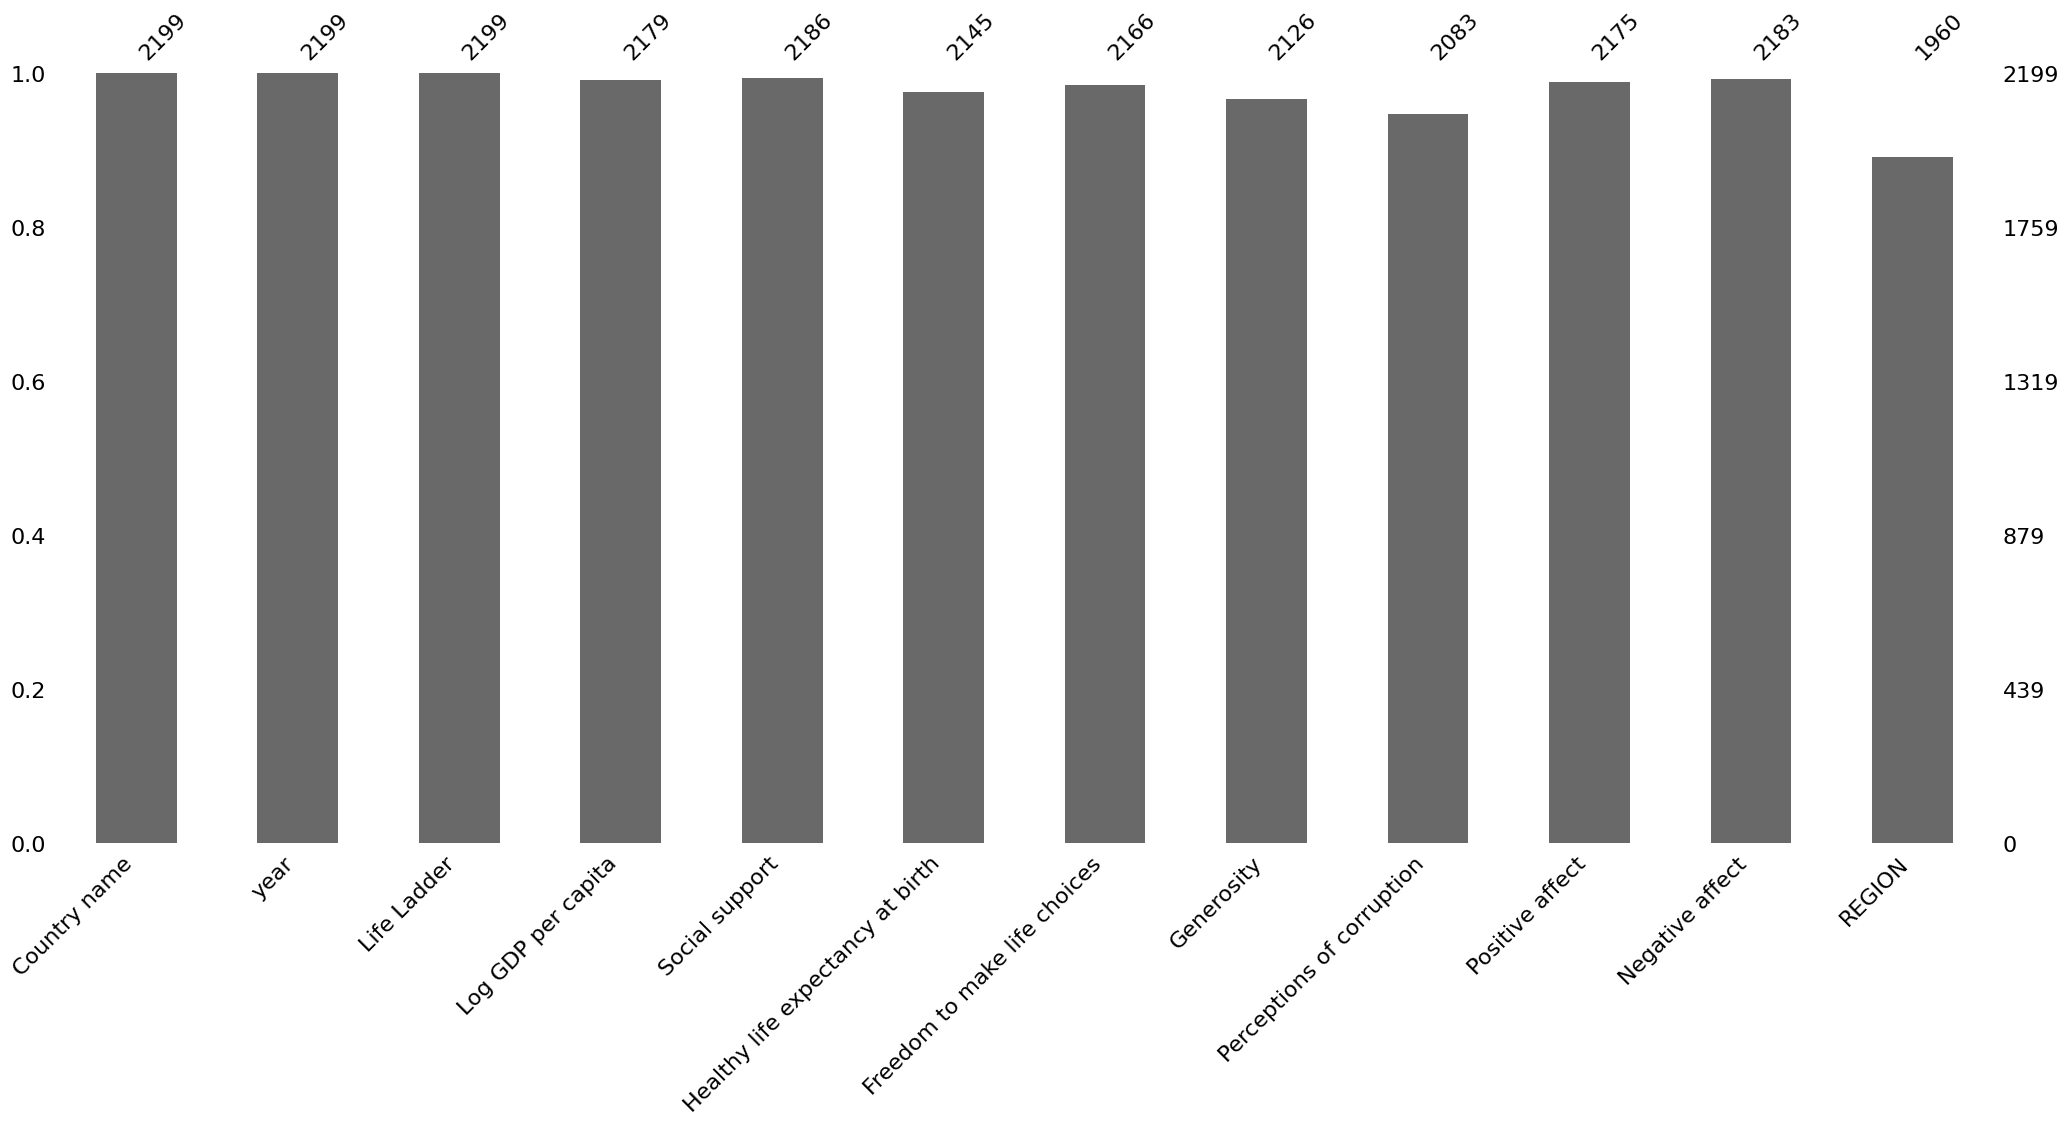

In [108]:
msno.bar(df);   #compare numbers to descriptive statistics above

**Столбчатая диаграмма** показывает долю и количество непустых значений в каждом столбце. Например, `REGION` заполнен примерно на 90% — некоторые страны не были найдены в таблице регионов. Переменные вроде `Generosity` или `Perceptions of corruption` могут иметь более низкий процент заполненности, так как эти вопросы задавались не во всехked in every country every year.

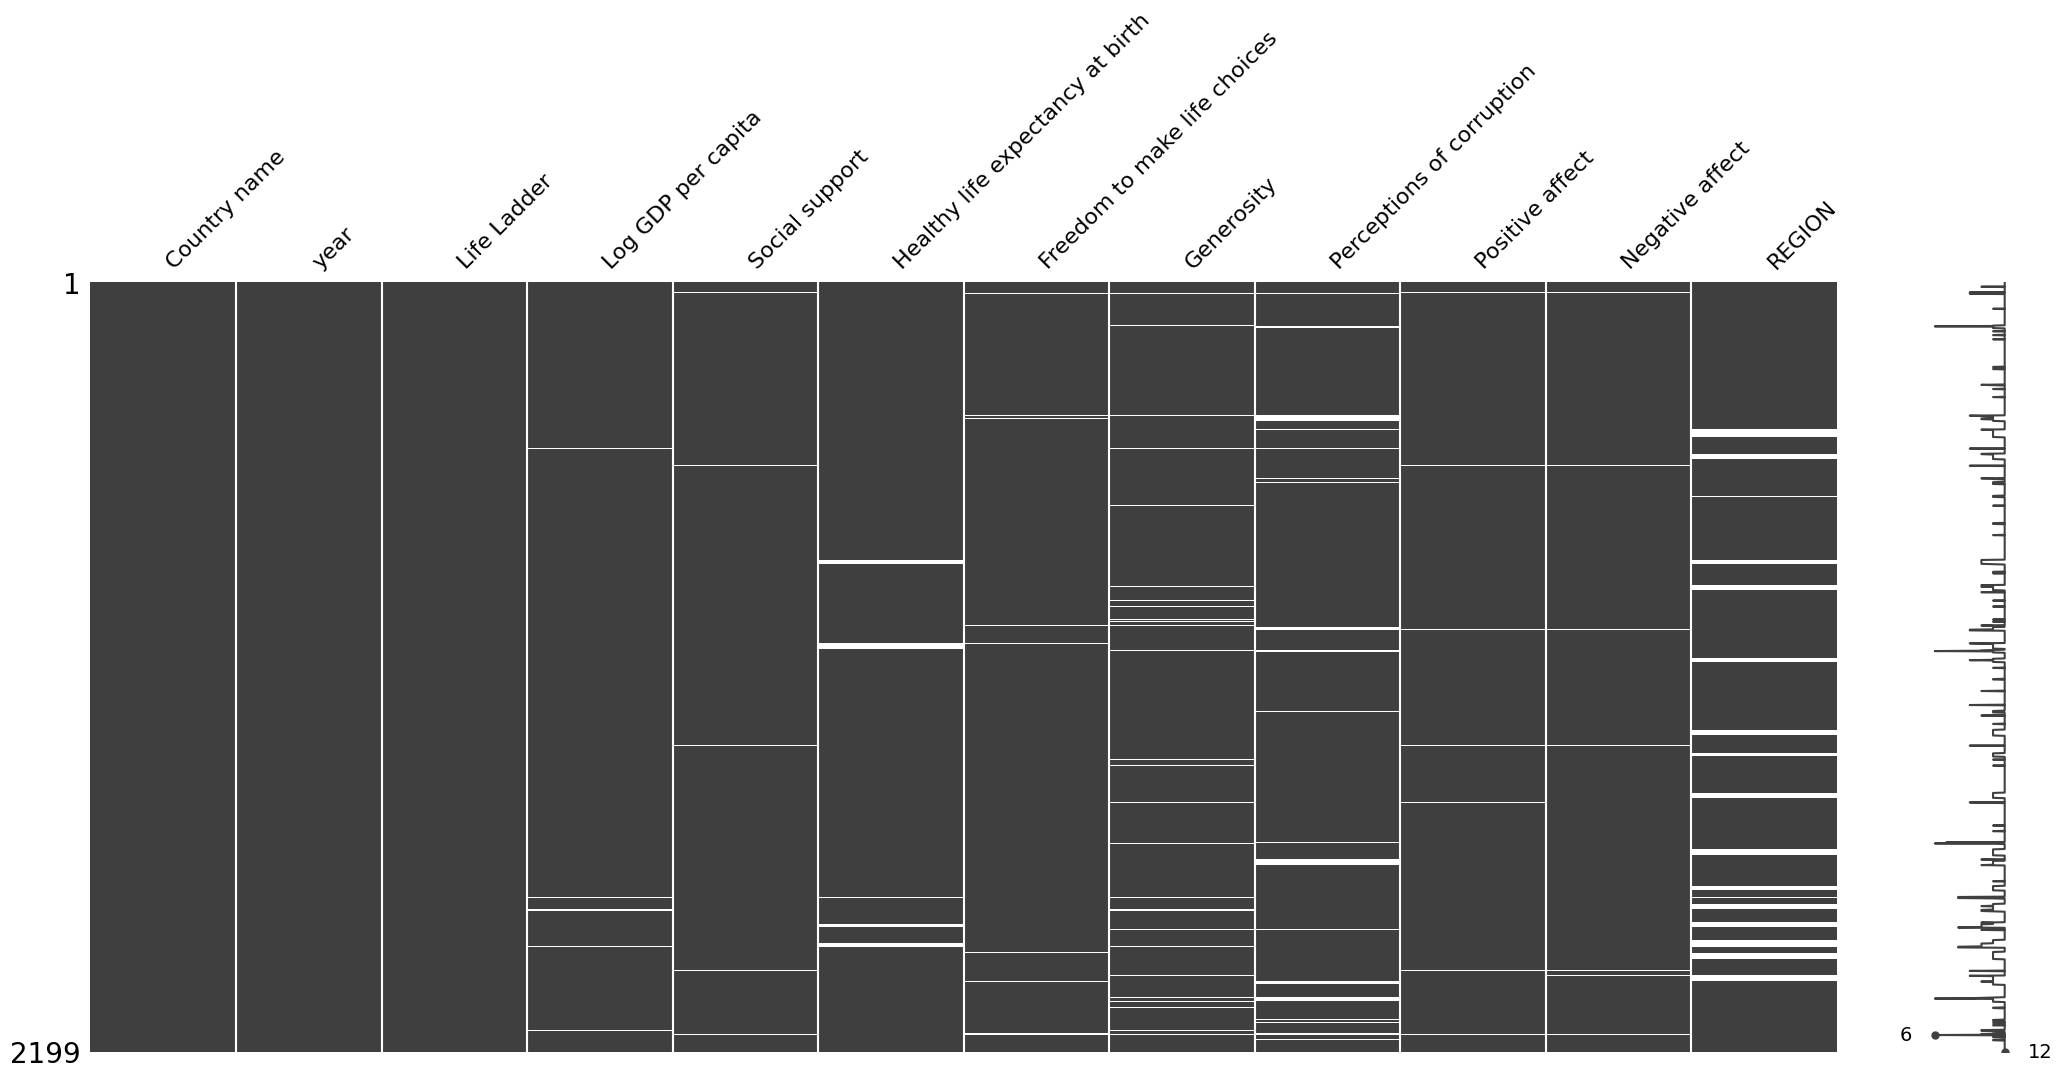

In [109]:
msno.matrix(df);

**Матричный график** показывает паттерн наличия/отсутствия значений по строкам. Каждый столбец — переменная; каждая строка — наблюдение; белый = пропуск.

Ищите **горизонтальные белые полосы** — это строки, где одновременно пропущены многие переменные. Это может указывать на то, что целая волна опроса для какой-то странtry was dropped, rather than isolated missing answers.

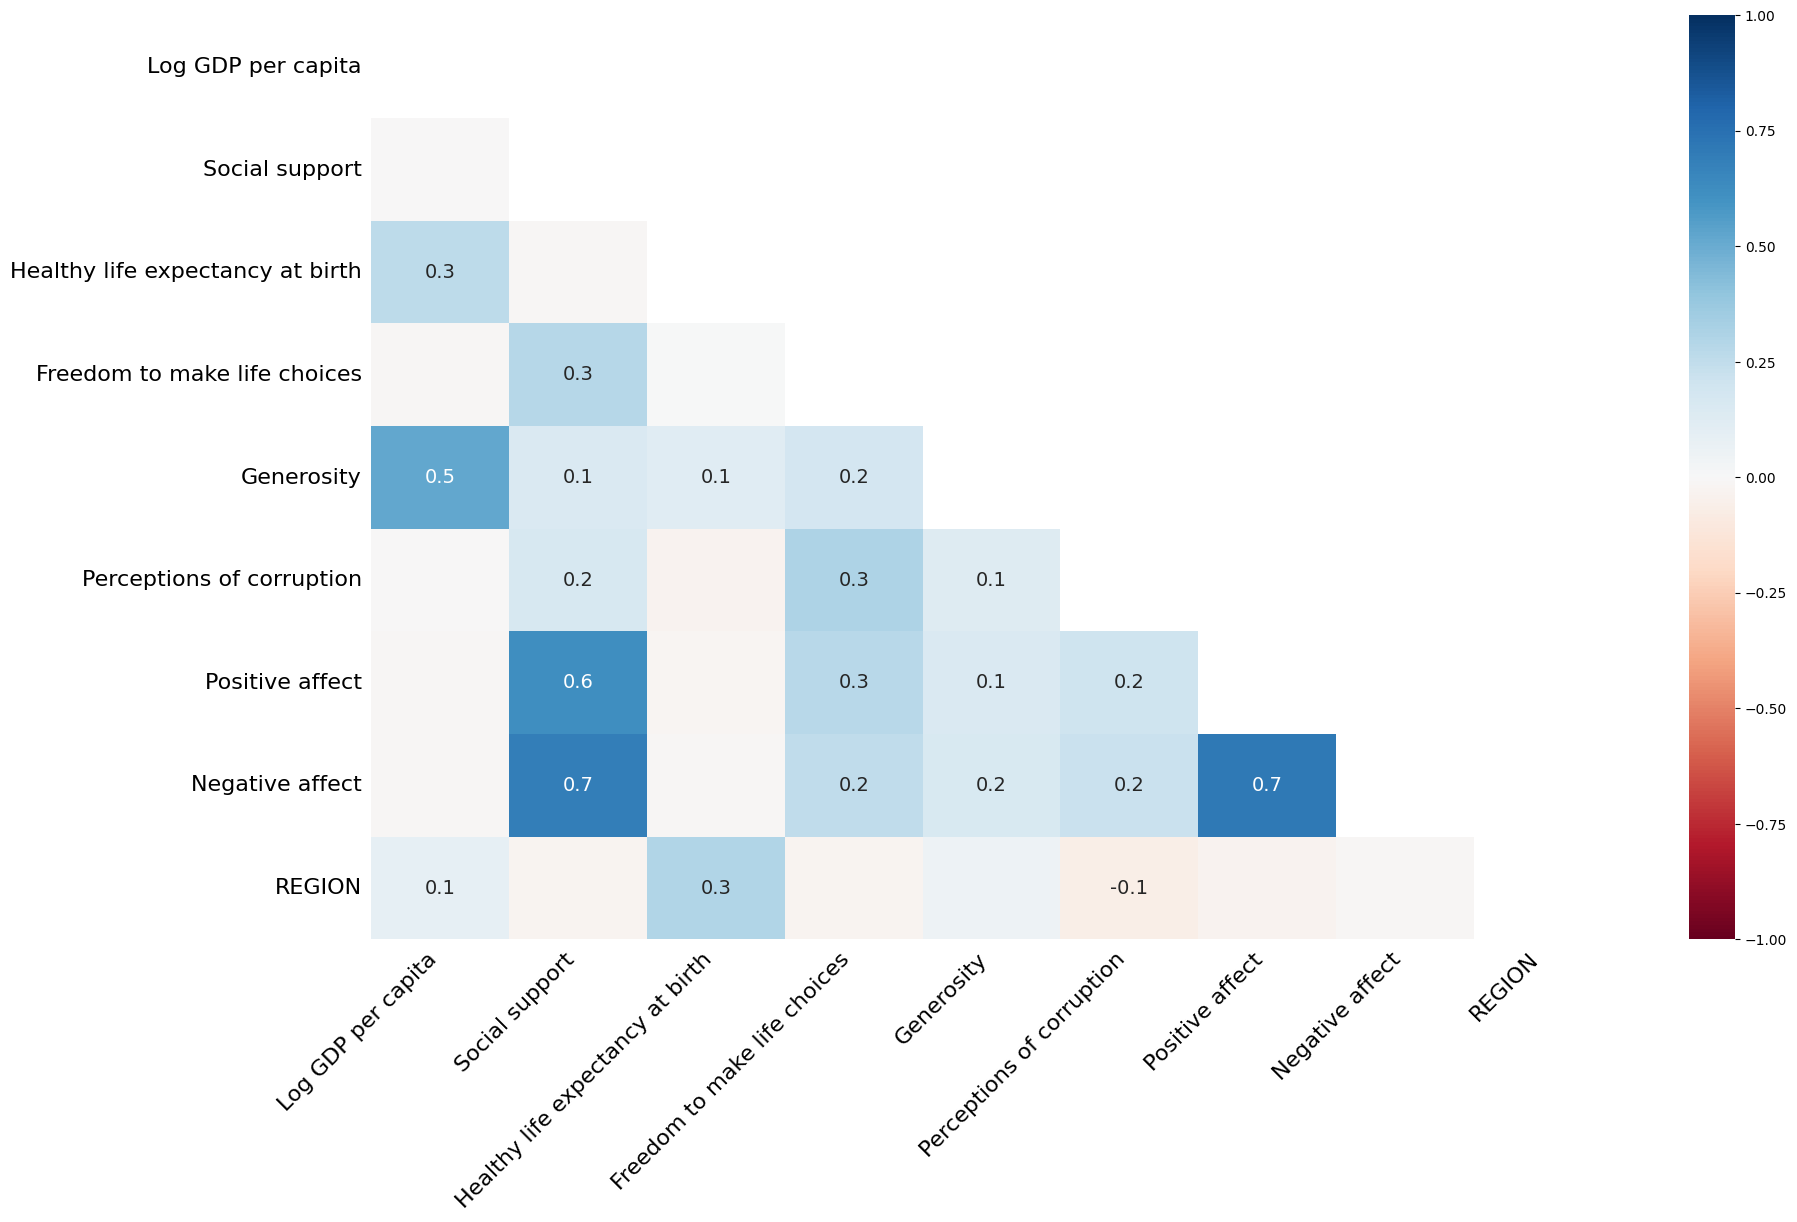

In [110]:
msno.heatmap(df);

**Тепловая карта** показывает корреляции между паттернами пропусков по переменным. Высокая положительная корреляция означает, что когда переменная A пропущена, переменная B тоже, как правило, пропущена — это указывает на **общую причину** (например, опрос не охватывал определённый блок вопросов для конкретной стран-year combination).

Here, absence of `Social support` data is highly correlated with missing `Positive affect` and `Negative affect` — these likely come from the same survey module.

Эти визуализации необходимы для решения **как** обрабатывать пропущенные данные. Правильная стратегия зависит от *типа* пропусков:

- **MCAR — пропуски полностью случайны.** Вероятность пропуска не связана ни с одной переменной, наблюдаемой или нет. Безопасно удалять такие строки без введения смещения.
- **MAR — пропуски случайны при условии наблюдаемых.** Пропуск зависит от других наблюдаемых переменных. Удаление вводит смещение — нужна импутация.
- **MNAR — пропуски не случайны.** Сама пропущенная величина определяет вероятность пропуска. Наиболее сложный случай — нужно моделировать механизм пропуска.roducing bias. Rare in practice.

- **MAR — Missing At Random.** Missingness is related to other *observed* variables but not to the missing value itself. Example: older respondents skip certain questions regardless of their actual answer. Imputation using observed variables is appropriate here.

- **MNAR — Missing Not At Random.** Missingness is related to the value of the missing variable itself or to unobserved factors. Example: people with very low income refuse to report it — so the missing values are *not* random; they cluster at the low end. Simple imputation introduces systematic bias. This is the hardest case and often requires domain knowledge or specialised models.

In practice: MCAR is testable (Little's test); MAR is assumed when tests pass; MNAR usually requires external knowledge to diagnose.

#### Заполнение пропущенных значений

**Импутация константным значением.**

Заменять пропуски нулём (или другой фиксированной константой) редко имеет смысл для непрерывных переменных — это искусственно снижает среднее и искажает распределение. Однако это уместно, когда 0 имеет содержательный смысл (например, отсутствие дохода)..g. 'did not donate' → Generosity = 0).

Both pandas and sklearn produce the same result; the sklearn approach becomes useful in pipelines where you need `fit`/`transform` separation between train and test sets.

In [111]:
df.fillna({'Social support' : 0}, inplace = False)['Social support'].describe()
#inplace = False as we don't want to save changes

count    2199.000000
mean        0.805887
std         0.135672
min         0.000000
25%         0.743763
50%         0.834280
75%         0.904607
max         0.987343
Name: Social support, dtype: float64

То же самое через **`SimpleImputer` из sklearn**. Ключевое преимущество: `imp.fit(train_data)` вычисляет заполняющее значение только на обучающей выборке, затем `imp.transform(test_data)` применяет то же значение — предотвращая утечку информации из тестовой выборки.

In [112]:
from sklearn.impute import SimpleImputer

df1 = df.copy()
imp = SimpleImputer(strategy = 'constant', fill_value = 0)
imp.fit(df1[['Social support']])
df1['Social support'] = imp.transform(df1[['Social support']])
df1['Social support'].describe()

count    2199.000000
mean        0.805887
std         0.135672
min         0.000000
25%         0.743763
50%         0.834280
75%         0.904607
max         0.987343
Name: Social support, dtype: float64

**Импутация статистической стратегией (среднее, медиана, наиболее частое).**

Это сохраняет центральную тенденцию переменной:
- **Среднее** — подходит для симметричных распределений без тяжёлых выбросов
- **Медиана** — предпочтительна для скошенных распределений; устойчива к выбросам
- **Наиболее частое** — используется для категориальных переменных categorical variables

Note: both mean and median imputation reduce the variance of the variable and can distort correlations between variables. Use with awareness.

In [113]:
df1 = df.copy()
df1['Social support'].fillna(df1['Social support'].median(), inplace = False).describe()
#inplace = False as we don't want to save changes

count    2199.000000
mean        0.810826
std         0.120609
min         0.228217
25%         0.747512
50%         0.835535
75%         0.904607
max         0.987343
Name: Social support, dtype: float64

То же самое через sklearn. Здесь `strategy='median'` вычисляет медиану на обучающих данных и последовательно применяет её.

In [114]:
df1 = df.copy()
imp = SimpleImputer(strategy = 'median')
df1['Social support'] = imp.fit_transform(df1[['Social support']])
df1['Social support'].describe()

count    2199.000000
mean        0.810826
std         0.120609
min         0.228217
25%         0.747512
50%         0.835535
75%         0.904607
max         0.987343
Name: Social support, dtype: float64

**Групповая импутация** — более информированный подход.

Когда данные имеют естественную группировку (здесь: страны, опрашиваемые несколько лет), использование центральной тенденции самой группы точнее, чем глобальное значение. Пропущенное значение счастья для Германии лучше заполнить медианой Германии, а не глобальной медианой.th the world median.

`groupby().transform('median')` broadcasts the group median back to every row of that group, so it aligns with the original DataFrame index and can be used directly in `.fillna()`.

In [115]:
df1 = df.copy()
df1['Social support'].fillna(df1\
                            .groupby('Country name')['Social support']\
                            .transform('median'), inplace = False)\
                            .describe()

count    2198.000000
mean        0.810712
std         0.120830
min         0.228217
25%         0.746609
50%         0.835717
75%         0.904690
max         0.987343
Name: Social support, dtype: float64

> Более продвинутые методы импутации мы рассмотрим позже: **импутация KNN** (заполнение значениями из похожих наблюдений) и **импутация на основе модели** (предсказание пропущенных значений с использованием других переменных как признаков).

#### Удаление пропущенных значений

**Полное удаление** (удаление каждой строки хотя бы с одним пропуском) — самая простая стратегия, и самая безопасная, когда пропуски MCAR и затрагивают небольшую долю строк.

Когда пропуски MAR или MNAR, полное удаление вводит **смещение выборки**: оставшиеся строки — не случайная выборка, и выводы по ним нельзя обобщить.ng sample is systematically different from the full population.

The `subset` parameter (commented out) lets you restrict deletion to rows missing in specific columns — useful when you only care about completeness for your key variables.

In [116]:
# Ваш код здесь. Saves result back to df (permanent change)
df = df.dropna(axis='index')
df.shape

(1765, 12)

После обработки дубликатов и пропусков мы готовы к анализу. Ответим на некоторые содержательные вопросы о региональных паттернах счастья.

### 6. Отбор, фильтрация, группировка и агрегация

Это основные операции манипуляции данными, которые вы будете использовать почти в каждом проекте. Вместе они образуют паттерн **разделить-применить-объединить**:
1. **Фильтрация** (разделение) — выбрать нужные строки
2. **Groupby** (дальнейшее разделение) — разбить строки по группам
3. **Агрегация** (применение) — вычислить сводную статистику для каждой группы
4. **Объединение** — собрать результаты обратно в одну таблицу a categorical variable
3. **Aggregate** (apply + combine) — compute a summary statistic per group

**In what region was average happiness highest in 2022?**

Steps:
- Filter to year 2022
- Group countries by region
- Compute mean happiness per region
- Sort descending

In [117]:
df[df.year==2022]\
.groupby('REGION')['Life Ladder']\
.mean().round(2).sort_values(ascending = False)

REGION
North America                    6.81
Europe                           6.46
Latin America                    6.21
South East Asia & Australasia    6.02
East Asia                        5.98
South Asia                       4.27
Africa & Middle East             4.24
Name: Life Ladder, dtype: float64

Посмотрим также, как счастье меняется во времени — агрегируя по всем странам для каждого года.

In [118]:
# Ваш код здесь
df.groupby('year')['Life Ladder'].agg(['count', 'mean', 'std']).round(2)

,count,mean,std
year,,,
2005,1,7.42,NaN
2006,67,5.21,1.15
2007,82,5.41,1.06
2008,91,5.48,1.25
2009,97,5.52,1.06
2010,101,5.54,1.18
2011,118,5.40,1.13
2012,110,5.46,1.18
2013,111,5.39,1.22


**Практическое задание:** Какая страна имела наивысший индекс счастья в 2022 году?

Паттерн: фильтрация → сортировка → взять верхнюю строку. Используйте `.sort_values(ascending=False).head(1)` для получения максимума.

In [119]:
# Ваш код здесь
# df[df.year == ...].sort_values(..., ascending=False).head(1)[['country', 'happiness']]

**Практическое задание:** Какие 5 самых счастливых и 5 наименее счастливых стран в среднем за все годы?

Паттерн: группировка по стране → агрегация средним → сортировка → взять верхние/нижние 5.

In [120]:
# Ваш код здесь
# df.groupby('country')['happiness'].mean().round(2).sort_values(ascending=False)

Немного о выборе столбцов. Для дальнейшего анализа нам не нужны переменные `affect` — удалим их.

`df.drop(columns=[...])` удаляет указанные столбцы. `inplace=True` изменяет DataFrame напрямую, не создавая копию. Используйте `inplace=False` (и присваивайте результат), если хотите сохранить оригинал.ight want to undo the operation.

In [121]:
# Ваш код здесь
df.drop(columns = ['Positive affect', 'Negative affect'], inplace = True)

/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/3497242758.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns = ['Positive affect', 'Negative affect'], inplace = True)


### 7. Переименование переменных

Имена столбцов в исходных данных часто непоследовательны — смешанный регистр, пробелы, специальные символы. Стандартизация имён в начале делает весь последующий код чище и менее подверженным ошибкам. С чистыми именами можно использовать точечную нотацию (`df.happiness`) вместо скобочной (`df['Life Ladder']`).adder']`), and you avoid quoting issues in `groupby`, `merge`, and model formulas.

> Best practice: rename right after loading the data. We placed this step later purely for pedagogical reasons — to show joins and grouping with the original names first.

**Step 1 — convert all column names to lowercase** using a function passed to `rename()`:

In [2]:
df.rename(str.lower, axis='columns', inplace = True)
df.columns

NameError: name 'df' is not defined

In [123]:
df.rename(columns = {'country name':'country',
                     'life ladder':'happiness',
                     'log gdp per capita':'log_gdp',
                     'social support':'social_support',
                     'healthy life expectancy at birth':'life_expectancy',
                     'freedom to make life choices':'freedom',
                     'perceptions of corruption':'corruption'},
         inplace = True)
df.columns

/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/1756821157.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns = {'country name':'country',


Index(['country', 'year', 'happiness', 'log_gdp', 'social_support',
       'life_expectancy', 'freedom', 'generosity', 'corruption', 'region'],
      dtype='object')

### 8. Обработка выбросов

Выбросы — точки данных, которые значительно отличаются от остальных. Они могут искажать статистический анализ и качество модели. Распространённые стратегии обнаружения:

| Метод | Правило | Лучше для |
|--------|------|----------|
| **МКР** | вне $[Q_1 - 1.5 \cdot IQR,\; Q_3 + 1.5 \cdot IQR]$ | Скошенные данные, надёжный |
| **Z-оценка** | $|z| > 3$ | Нормально распределённые данные |
| **Визуальный** | Ящиковые графики, гистограммы | Первичный осмотр |

#### 8.1. Визуализация выбросов

Перед выбором метода обнаружения всегда полезно **посмотреть на данные**. Ящиковый график — классический инструмент: ящик охватывает межквартильный размах (IQR = Q3 − Q1), линия внутри — медиана, а отдельные точки за усами — потенциальные выбросы. Гистограмма дополняет его, показывая форму всего распределения.ogram helps you see the overall shape of the distribution.

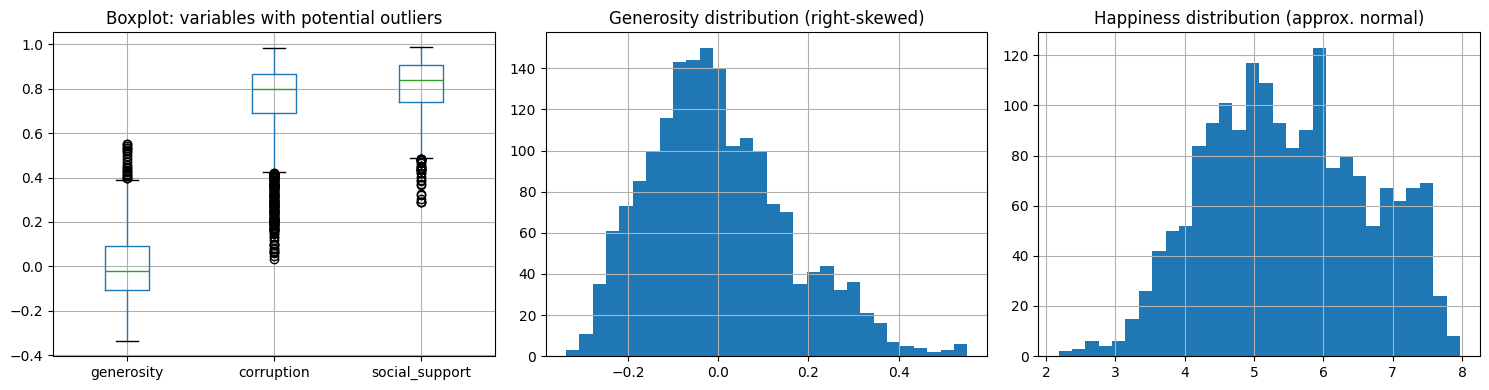

Generosity skewness: 0.602
Happiness  skewness: 0.008


In [124]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ящиковые графики — generosity и corruption обычно имеют видимые выбросы в данных WHR
df[['generosity', 'corruption', 'social_support']].boxplot(ax=axes[0])
axes[0].set_title('Ящиковый график: переменные с возможными выбросами')

# Распределение generosity — скос вправо, выбросы на правом хвосте
df['generosity'].hist(bins=30, ax=axes[1])
axes[1].set_title('Распределение Generosity (скос вправо)')

# Распределение happiness для сравнения — намного симметричнее, меньше выбросов
df['happiness'].hist(bins=30, ax=axes[2])
axes[2].set_title('Распределение Happiness (приблизительно нормальное)')

plt.tight_layout()
plt.show()

print('Generosity skewness:', df['generosity'].skew().round(3))
print('Happiness  skewness:', df['happiness'].skew().round(3))

#### 8.2. Метод МКР (межквартильный размах)

**Межквартильный размах (IQR)** = Q3 − Q1 — ширина среднего 50% данных. Значение считается выбросом, если оно ниже $Q_1 - 1{,}5 \cdot IQR$ или выше $Q_3 + 1{,}5 \cdot IQR$. Эти пороги соответствуют концам усов на стандартном ящиковом графике.

Правило МКР **устойчиво**: оно не зависит от среднего или стандартного отклонения, поэтому хорошо работает даже при скошенных распределениях или когда в данных уже есть экстремальные значения.

Применяем его к `generosity` — переменной со скосом вправо, где выбросы явно присутствуют.

In [125]:
Q1 = df['generosity'].quantile(0.25)
Q3 = df['generosity'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['generosity'] < lower) | (df['generosity'] > upper)]
print(f'IQR bounds: [{lower:.3f}, {upper:.3f}]')
print(f'Outliers detected: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.1f}%)')
outliers_iqr[['country', 'year', 'generosity']].sort_values('generosity', ascending=False)

IQR bounds: [-0.407, 0.389]
Outliers detected: 23 (1.3%)


,country,year,generosity
861,Indonesia,2019,0.551963
1941,Thailand,2014,0.550825
863,Indonesia,2021,0.542997
1937,Thailand,2010,0.533929
862,Indonesia,2020,0.531598
1936,Thailand,2009,0.522777
864,Indonesia,2022,0.518823
860,Indonesia,2018,0.508754
858,Indonesia,2016,0.496852
859,Indonesia,2017,0.484792


#### 8.3. Метод Z-оценки

**Z-оценка** измеряет, на сколько стандартных отклонений значение удалено от среднего:

$$z_i = \frac{x_i - \mu}{\sigma}$$

A common threshold is $|z| > 3$: under a normal distribution only ~0.3 % of observations fall outside this range, so anything beyond it is considered unusually extreme.

We apply it to `corruption` — where a few extremely low values (high perceived corruption) form the outliers.

> **Note:** Z-score assumes approximate normality. For `generosity` (right-skewed) the IQR method above is more appropriate — notice how the two methods find different observations.

In [126]:
from scipy.stats import zscore

z_scores = zscore(df['corruption'].dropna())
outliers_z = df.loc[df['corruption'].dropna().index][abs(z_scores) > 3]
print(f'Z-score outliers in corruption (|z| > 3): {len(outliers_z)}')
outliers_z[['country', 'year', 'corruption']].sort_values('corruption')

Z-score outliers in corruption (|z| > 3): 23


,country,year,corruption
1713,Singapore,2009,0.035198
1719,Singapore,2016,0.047311
1714,Singapore,2010,0.060282
1711,Singapore,2007,0.063615
1712,Singapore,2008,0.065775
1722,Singapore,2019,0.069620
1642,Rwanda,2014,0.078000
1640,Rwanda,2012,0.081325
1643,Rwanda,2015,0.094604
1721,Singapore,2018,0.096563


#### 8.4. Обработка выбросов

Три распространённых стратегии:
- **Удаление** — только когда выбросы явно являются ошибками ввода данных
- **Обрезка (винзоризация)** — замена экстремальных значений граничным значением
- **Преобразование** — применение log/sqrt для уменьшения влияния хвоста

Ниже мы **обрезаем** `generosity` до границ IQR:` to the IQR bounds computed above. Observe how max and std change, while mean and median stay close:

         before     after
count  1765.000  1765.000
mean     -0.000    -0.001
std       0.156     0.153
min      -0.338    -0.338
25%      -0.108    -0.108
50%      -0.019    -0.019
75%       0.091     0.091
max       0.552     0.389


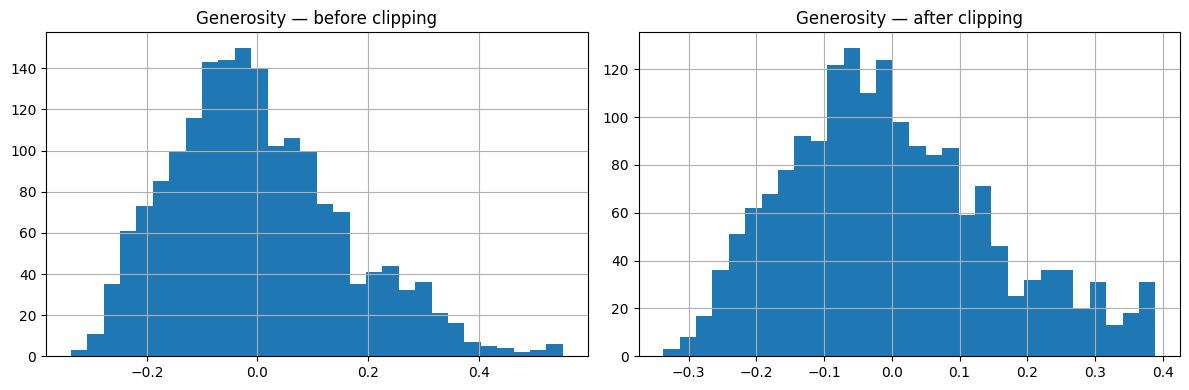

In [127]:
df1 = df.copy()
df1['generosity'] = df1['generosity'].clip(lower=lower, upper=upper)

comparison = pd.DataFrame({
    'before': df['generosity'].describe().round(3),
    'after':  df1['generosity'].describe().round(3)
})
print(comparison)

# Visualise the effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['generosity'].hist(bins=30, ax=axes[0])
axes[0].set_title('Generosity — before clipping')
df1['generosity'].hist(bins=30, ax=axes[1])
axes[1].set_title('Generosity — after clipping')
plt.tight_layout()
plt.show()

# Ваш код здесь — apply the same IQR clipping to 'corruption'
# Q1 = ...
# Q3 = ...
# IQR = ...
# df1['corruption'] = df1['corruption'].clip(lower=..., upper=...)

### 9. Перекодирование числовых переменных

Многие алгоритмы ML чувствительны к **масштабу** входных переменных. Переменная в диапазоне от 0 до 100 000 будет доминировать над переменной от 0 до 1 в любом алгоритме, вычисляющем расстояния или скалярные произведения — не потому что она важнее, а просто из-за разницы в масштабе.its larger numerical range.

Affected algorithms include: **k-Nearest Neighbours**, **k-Means**, **SVM**, **linear/logistic regression with regularisation** (Lasso, Ridge), and **neural networks**.

Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are *not* affected — they split on thresholds and do not care about absolute scale.

Let's check the current scales of our variables:

In [128]:
df.head()

,country,year,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption,region
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,South Asia
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,South Asia
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,South Asia
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,South Asia
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,South Asia


#### 9.1. Линейное преобразование (нормализация)

**Линейное** преобразование применяет одну и ту же арифметическую операцию к каждому значению. Оно сдвигает и масштабирует данные, но **не** меняет форму распределения — скошенная переменная остаётся скошенной; нормальная остаётся нормальной.

Два распространённых метода линейного масштабирования:ear scalers:

| Scaler | Formula | Result | Use when |
|--------|---------|--------|----------|
| **StandardScaler** | $x' = (x - \mu) / \sigma$ | mean=0, std=1 | Distribution shape unknown or normal |
| **MinMaxScaler** | $x' = (x - x_{min}) / (x_{max} - x_{min})$ | range [0, 1] | Fixed known range, no outliers |

#### Стандартизация (Z-масштабирование)

$$x'_i = \frac{x_i - \mu}{\sigma}$$

После стандартизации: среднее = 0, std = 1. Относительные расстояния между наблюдениями сохраняются; меняется только единица измерения.

**Вручную** — полезно для понимания, что формула на самом деле делает:

In [129]:
((df.happiness - df.happiness.mean()) / df.happiness.std()).head(10)

0   -1.527094
1   -0.942429
2   -0.635002
3   -1.433876
4   -1.475931
5   -1.657693
6   -2.038055
7   -1.303582
8   -1.098994
9   -2.442533
Name: happiness, dtype: float64

**С `StandardScaler` из sklearn** — рекомендуемый подход в ML-пайплайнах.

Разделение `fit` / `transform` критически важно:
- `fit(X_train)` — вычисляет и сохраняет μ и σ **только на обучающих данных**
- `transform(X_test)` — применяет те же μ и σ к тестовым данным

Если применить fit на полных данных, вы допустите **утечку данных** из тестовой выборки.dataset (including test), you leak information about the test set into your preprocessing — this is a form of **data leakage** that makes evaluation unreliable.

In [130]:
from sklearn.preprocessing import StandardScaler

st_scaler = StandardScaler().fit(df.iloc[:,2:-1])   #here we calculate means and SDs
st_scaler.mean_, st_scaler.scale_

(array([ 5.49495722e+00,  9.34925951e+00,  8.09887861e-01,  6.31867677e+01,
         7.52376289e-01, -4.61405052e-04,  7.41496648e-01]),
 array([1.15963076, 1.16779092, 0.12545582, 7.17938457, 0.14052289,
        0.15625367, 0.19054054]))

In [131]:
df1 = st_scaler.transform(df.iloc[:,2:-1])
df1 = pd.DataFrame(df1,
                   columns = df.iloc[:,2:-1].columns)  #to change the columns names
df1.head()

,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption
0,-1.527527,-1.711645,-2.863363,-1.767111,-0.243818,1.075903,0.735747
1,-0.942696,-1.576150,-2.053148,-1.725325,-0.522904,1.224101,0.569636
2,-0.635182,-1.486019,-2.158630,-1.683538,-1.083447,0.779357,-0.182274
3,-1.434282,-1.513970,-2.301880,-1.641752,-1.825147,1.049786,-0.054519
4,-1.476349,-1.446110,-2.305601,-1.599965,-1.575838,1.523478,0.179086


Преобразование полностью **обратимо** через `inverse_transform()`. Это полезно, когда нужно представить предсказания в исходных единицах после моделирования.

In [132]:
df1 = pd.DataFrame(st_scaler.inverse_transform(df1),
                   columns = df.iloc[:,2:-1].columns)
df1.head()

,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption
0,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686
1,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035
2,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766
3,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109
4,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620


#### 9.2. Нелинейное преобразование

Линейное масштабирование не меняет форму распределения. Если переменная сильно скошена или имеет экстремальные выбросы, одного масштабирования может быть недостаточно — многие модели предполагают (или выигрывают от) приблизительно нормальных входных данных.

**Нелинейное преобразование** меняет форму распределения, сжимая большие значения ближе друг к другу.he shape of the distribution:

| Transformation | Formula | Best for |
|----------------|---------|----------|
| **Log** | $x' = \log(x)$ | Right-skewed, strictly positive values (income, GDP) |
| **Square root** | $x' = \sqrt{x}$ | Moderately right-skewed, includes zeros |
| **Box-Cox** | parametric | General-purpose, requires positive values |
| **Yeo-Johnson** | parametric | General-purpose, allows zeros and negatives |

In our data `log_gdp` is already the log of GDP. Let's see what happens when we reverse it:

In [133]:
df.log_gdp.describe()

count    1765.000000
mean        9.349260
std         1.168122
min         5.526723
25%         8.447203
50%         9.479447
75%        10.327725
max        11.663788
Name: log_gdp, dtype: float64

In [134]:
np.exp(df.log_gdp).describe()

count      1765.000000
mean      20241.301530
std       20277.721021
min         251.319085
25%        4662.013347
50%       13087.951653
75%       30568.501971
max      116283.661380
Name: log_gdp, dtype: float64

In [135]:
from scipy.stats import skew, kurtosis

print(skew(df.log_gdp), skew(np.exp(df.log_gdp)))

-0.30262899569791224 1.6219834067762529


Отрицательный скос в `log_gdp` (уже преобразованном) умеренный — близкий к нормальному. После потенцирования обратно в сырой ВВП скошенность намного более выражена: несколько очень богатых стран сильно тянут правый хвост.

**Q-Q график** — стандартный диагностический инструмент нормальности: если точки следуют диагональной прямой — распределение близко к нормальному.agonal, the distribution is approximately normal. Systematic curves above/below the line indicate skewness or heavy tails.

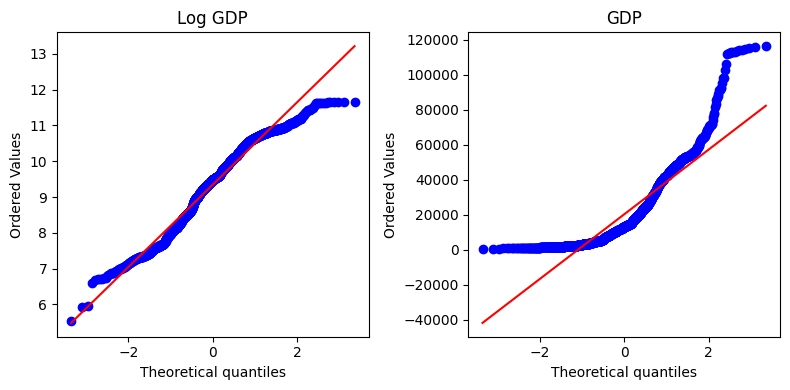

In [136]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))

probplot(df.log_gdp, dist = 'norm', plot = ax[0])
ax[0].set_title('Log GDP')

probplot(np.exp(df.log_gdp), dist = 'norm', plot = ax[1])
ax[1].set_title('GDP')

plt.tight_layout()
plt.show()

Подробнее о линейных и нелинейных преобразованиях можно прочитать [здесь](https://www.kaggle.com/code/ohseokkim/linear-nonlinear-scaling)

#### 9.3. Бинаризация (дискретизация)

Иногда преобразование непрерывной переменной в упорядоченные категории даёт более интерпретируемый результат, чем сохранение исходной шкалы — например, в медицинских исследованиях «высокий ИМТ» vs «нормальный ИМТ» часто информативнее, чем ИМТ = 27,3.

Два подхода к разбиению на интервалы:

| Стратегия | Метод | Ширина интервалов | Количество наблюдений |
|----------|--------|------------|------------|
| **Равные интервалы** | `pd.cut()` | Одинаковая | Разное (проблема для скошенных данных) |
| **Квантильное (равночастотное)** | `pd.qcut()` | Разная | Одинаковое |

Посмотрим, что даёт разбиение на равные интервалы для `social_support`:

In [137]:
df.social_support.value_counts(bins = 3, sort = False)

(0.288, 0.523]      57
(0.523, 0.755]     441
(0.755, 0.987]    1267
Name: count, dtype: int64

Границы интервалов почти равные (~0,230 между ними). Но обратите внимание на неравное количество наблюдений — распределение неравномерно, поэтому большинство наблюдений концентрируется в среднем интервале.

In [138]:
min_value = df.social_support.min()
max_value = df.social_support.max()

bins = np.linspace(min_value, max_value, 4)   #+1 edge
bins
labels = ['low', 'medium', 'high']
df['social_support_cut'] = pd.cut(df.social_support,
                              bins = bins,
                              labels = labels,
                              include_lowest = True)
df.social_support_cut.value_counts()

/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/430881790.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['social_support_cut'] = pd.cut(df.social_support,


social_support_cut
high      1267
medium     441
low         57
Name: count, dtype: int64

Разбиение на равные интервалы дало очень мало наблюдений в категории «низкий» — это может сделать группу статистически ненадёжной. Квантильное разбиение решает эту проблему, обеспечивая равное количество в каждом интервале, за счёт неравных промежутков между границами.

In [139]:
# pd.qcut — квантильное разбиение (равночастотное)
# Каждый интервал будет содержать примерно одинаковое число наблюдений
# (в отличие от pd.cut, который использует равные по ширине интервалы)

df['social_support_cut2'], boundaries = pd.qcut(
    df.social_support,
    q = 3,              # количество интервалов (разрез на 33-м и 66-м перцентилях)
    precision = 1,      # округлить метки границ интервалов до 1 десятичного знака
    labels = labels,    # назначить пользовательские названия категорий вместо записи интервала
    retbins = True      # также вернуть фактические значения границ как массив numpy
)

# boundaries — массив из 4 точек разреза: [min, 33-й пер, 66-й пер, max]
# Это неравные интервалы — ожидаемо при квантильном разбиении
print('Bin boundaries:', boundaries.round(3))

# Проверяем, что в каждой категории примерно одинаковое количество
df['social_support_cut2'].value_counts()

Bin boundaries: [0.29  0.779 0.891 0.987]


/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/296564538.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['social_support_cut2'], boundaries = pd.qcut(


social_support_cut2
low       589
medium    588
high      588
Name: count, dtype: int64

Теперь в каждой категории одинаковое количество наблюдений. Промежутки между границами неравные — группа «низкий» более плотно упакована внизу, а «высокий» охватывает более широкий диапазон.

**Что выбрать?** Зависит от цели:
- Если нужны группы равного размера (например, для стратифицированного эксперимента) → квантильное разбиение
- Если границы интервалов имеют содержательный смысл (например, 0–0.33 = низкая поддержка) → равные интервалы
- Если нужно минимизировать дисперсию внутри интервалов → используйте `KBinsDiscretizer(strategy='kmeans')`

Те же операции через **`KBinsDiscretizer` из sklearn**.

Ключевой параметр: `encode='ordinal'` возвращает целочисленные коды (0, 1, 2). Альтернатива: `encode='onehot'` возвращает разреженную бинарную матрицу — эквивалент прямого one-hot кодирования интервалов.

In [140]:
from sklearn.preprocessing import KBinsDiscretizer

est = KBinsDiscretizer(n_bins = 3, encode = 'ordinal',
                       strategy = 'uniform', subsample = None)

est.fit(df[['social_support']])
print(est.bin_edges_)
np.unique(est.transform(df[['social_support']]), return_counts = True)

[array([0.29018417, 0.52257061, 0.75495705, 0.98734349])]


(array([0., 1., 2.]), array([  57,  441, 1267]))

In [141]:
est = KBinsDiscretizer(n_bins = 3, encode = 'ordinal', strategy = 'quantile')
est.fit(df[['social_support']])
print(est.bin_edges_)
np.unique(est.transform(df[['social_support']]), return_counts = True)

[array([0.29018417, 0.77866179, 0.89128244, 0.98734349])]


(array([0., 1., 2.]), array([588, 588, 589]))

### 10. Перекодирование нечисловых переменных

Большинство алгоритмов ML ожидают числовых входных данных. Категориальные переменные нужно преобразовать в числа. Правильный метод кодирования зависит от **природы** переменной:

| Тип переменной | Пример | Рекомендуемое кодирование |
|---------------|---------|----------------------|
| Бинарная (2 категории) | да / нет | Label Encoding |
| Порядковая (упорядоченные категории) | низкий / средний / высокий | Ordinal Encoding |
| Номинальная, мало категорий (≤ ~15) | регион | One-Hot Encoding |
| Номинальная, много категорий (> ~15) | название страны | Target / Frequency Encoding |

#### 10.1. Перекодирование значений

Перед кодированием может понадобиться **упростить или объединить категории** — на основе предметных знаний. Меньше категорий = меньше дамми-переменных после one-hot кодирования и более стабильные оценки модели, особенно когда некоторые категории имеют мало наблюдений.

> **Практическое правило:** не объединяйте категории вслепую. Всегда проверяйте, действительно ли объединяемые группы имеют схожие распределения целевой переменной.

In [142]:
df.region.value_counts().sort_index()

region
Africa & Middle East             525
East Asia                         30
Europe                           629
Latin America                    323
North America                     31
South Asia                        94
South East Asia & Australasia    133
Name: count, dtype: int64

In [143]:
df['region_large'] = df.region.replace({"South Asia":"Asia",
                                        "East Asia":"Asia",
                                        "South East Asia & Australasia":"Asia",
                                       })
df.region_large.value_counts().sort_index()

/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/3629154508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['region_large'] = df.region.replace({"South Asia":"Asia",


region_large
Africa & Middle East    525
Asia                    257
Europe                  629
Latin America           323
North America            31
Name: count, dtype: int64

Аналогично, трёхуровневую порядковую переменную можно свернуть в бинарную. Это имеет смысл, когда две нижние группы ведут себя схожим образом в отношении целевой переменной, или когда вам просто нужен бинарный предиктор.

In [144]:
# Ваш код здесь
df['social_support_high'] = df.social_support_cut2.replace({"low":"no",
                                        "medium":"no",
                                        "high":"yes",
                                       })
df.social_support_high.value_counts().sort_index()

/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/2767835463.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['social_support_high'] = df.social_support_cut2.replace({"low":"no",
/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/2767835463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['social_support_high'] = df.social_support_cut2.replace({"low":"no",


social_support_high
no     1177
yes     588
Name: count, dtype: int64

Для большинства моделей нужно кодировать категории числами. Существует три основных стратегии — каждая корректна в разных ситуациях:

- **Label encoding** — для бинарных переменных
- **Ordinal encoding** — для упорядоченных категорий
- **One-hot encoding** — для номинальных (неупорядоченных) категорий

#### 10.2. Label encoding (кодирование метками)

`LabelEncoder` по умолчанию сопоставляет каждую категорию целому числу в **алфавитном порядке**: `no → 0`, `yes → 1`. Принимает **1D Series** на вход.

**Когда использовать:** только для бинарных переменных. Для 3+ неупорядоченных категорий это кодирование навязывает произвольный **порядок и расстояние**. Для таких случаев используйте One-Hot Encoding. example, alphabetical encoding gives `Americas=0, Asia=1, Europe=2` — the model will treat Asia as "between" Americas and Europe, and assume that Americas and Asia are more similar than Americas and Europe. These relationships are entirely fictional and introduce bias in linear and distance-based models.

After fitting, `labelencoder.classes_` shows which integer corresponds to which label.

In [145]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
df.loc[:, 'social_support_high_lenc'] = labelencoder.fit_transform(df.loc[:, 'social_support_high'])
print(labelencoder.classes_)
df.head()

['no' 'yes']


/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/2277168690.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'social_support_high_lenc'] = labelencoder.fit_transform(df.loc[:, 'social_support_high'])


,country,year,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption,region,social_support_cut,social_support_cut2,region_large,social_support_high,social_support_high_lenc
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,South Asia,low,low,Asia,no,0
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,South Asia,medium,low,Asia,no,0
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,South Asia,medium,low,Asia,no,0
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,South Asia,low,low,Asia,no,0
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,South Asia,low,low,Asia,no,0


In [146]:
df.social_support_high_lenc.value_counts().sort_index()

social_support_high_lenc
0    1177
1     588
Name: count, dtype: int64

#### 10.3. Ordinal encoding (порядковое кодирование)

`OrdinalEncoder` также сопоставляет категории целым числам, но позволяет **явно определить порядок** — это критически важно. Без параметра `categories` sklearn сортирует по алфавиту: `high=0, low=1, medium=2` — это не корректно и не просто обратный порядок, это **перемешанный** порядок.d**: `low` ends up numerically above `medium`, while `high` sits at zero. The model gets a completely meaningless scale.

Unlike `LabelEncoder`, it takes a **2D array** (a DataFrame, not a Series), which allows encoding multiple ordered columns at once.

**When to be cautious:** linear models treat the gap between 0→1 and 1→2 as equal. If the true effect of going from *low* to *medium* differs from *medium* to *high*, one-hot encoding is safer even for ordinal variables.

Result: `low → 0.0`, `medium → 1.0`, `high → 2.0`

In [147]:
from sklearn.preprocessing import OrdinalEncoder

ordinalencoder = OrdinalEncoder(categories = [['low', 'medium', 'high']])
df.loc[:, 'social_support_cut2_oenc'] = ordinalencoder.fit_transform(df.loc[:, 'social_support_cut2'].to_frame())
print(ordinalencoder.categories_)
df.head()

[array(['low', 'medium', 'high'], dtype=object)]


/var/folders/1c/lnxbjb_177d8cf5hmlxdbv340000gn/T/ipykernel_89130/4018630524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'social_support_cut2_oenc'] = ordinalencoder.fit_transform(df.loc[:, 'social_support_cut2'].to_frame())


,country,year,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption,region,social_support_cut,social_support_cut2,region_large,social_support_high,social_support_high_lenc,social_support_cut2_oenc
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,South Asia,low,low,Asia,no,0,0.0
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,South Asia,medium,low,Asia,no,0,0.0
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,South Asia,medium,low,Asia,no,0,0.0
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,South Asia,low,low,Asia,no,0,0.0
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,South Asia,low,low,Asia,no,0,0.0


In [148]:
df.social_support_cut2_oenc.value_counts().sort_index()

social_support_cut2_oenc
0.0    589
1.0    588
2.0    588
Name: count, dtype: int64

#### 10.4. One-hot encoding (однократное кодирование)

One-hot encoding создаёт **отдельный бинарный столбец для каждой категории**. Строка получает `1` в столбце, соответствующем её категории, и `0` во всех остальных:

```
Europe → [1, 0, 0, 0]
Asia   → [0, 1, 0, 0]
Africa → [0, 0, 1, 0]
```

Это правильный выбор для **номинальных (неупорядоченных) переменных** с небольшим числом категорий.es** (no inherent order).

**Key parameters of `OneHotEncoder`:**
- `sparse_output=False` — return a dense array (easier to work with for small datasets)
- `drop='first'` — drop one column per variable to avoid the **dummy variable trap**: with $k$ categories you only need $k-1$ columns, because the dropped category is implicitly encoded as *all zeros*. Without this, the columns are perfectly collinear, which breaks models that invert the feature matrix (e.g. linear regression)
- `handle_unknown='ignore'` — if the test set contains an unseen category, encode it as all zeros instead of raising an error. Always set this in production

**When to be cautious:** variables with many categories (e.g. 150+ countries) produce very wide matrices — with `sparse_output=False` these are dense and heavy in memory; with `sparse_output=True` they are stored efficiently but many downstream libraries do not accept sparse input. Either way: slow training and risk of overfitting on rare categories. In such cases consider **target encoding** (replace category with mean of the target) or **frequency encoding** (replace with category frequency).

In [149]:
from sklearn.preprocessing import OneHotEncoder

onehotencoder = OneHotEncoder(sparse_output = False, drop = 'first')

df_ohe = pd.DataFrame(onehotencoder.fit_transform(df[['region_large']]))
df_ohe.columns = onehotencoder.get_feature_names_out()
df_ohe.head()
df_onehot = df_ohe.join(df)
df_onehot

,region_large_Asia,region_large_Europe,region_large_Latin America,region_large_North America,country,year,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption,region,social_support_cut,social_support_cut2,region_large,social_support_high,social_support_high_lenc,social_support_cut2_oenc
0,1.0,0.0,0.0,0.0,Afghanistan,2008.0,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,South Asia,low,low,Asia,no,0.0,0.0
1,1.0,0.0,0.0,0.0,Afghanistan,2009.0,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,South Asia,medium,low,Asia,no,0.0,0.0
2,1.0,0.0,0.0,0.0,Afghanistan,2010.0,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,South Asia,medium,low,Asia,no,0.0,0.0
3,1.0,0.0,0.0,0.0,Afghanistan,2011.0,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,South Asia,low,low,Asia,no,0.0,0.0
4,1.0,0.0,0.0,0.0,Afghanistan,2012.0,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,South Asia,low,low,Asia,no,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,0.0,0.0,0.0,0.0,South Africa,2007.0,5.204454,9.497471,0.788308,46.900002,0.689988,-0.166128,0.858651,Africa & Middle East,high,medium,Africa & Middle East,no,0.0,1.0
1761,0.0,0.0,0.0,0.0,South Africa,2008.0,5.346307,9.517552,0.809542,47.799999,0.748846,-0.103980,0.865791,Africa & Middle East,high,medium,Africa & Middle East,no,0.0,1.0
1762,0.0,0.0,0.0,0.0,South Africa,2009.0,5.218431,9.490159,0.877359,48.700001,0.739410,-0.162481,0.904342,Africa & Middle East,high,medium,Africa & Middle East,no,0.0,1.0
1763,0.0,0.0,0.0,0.0,South Africa,2010.0,4.652429,9.508173,0.917056,49.599998,0.738906,-0.211053,0.790629,Africa & Middle East,high,high,Africa & Middle East,yes,1.0,2.0


In [150]:
df_onehot.drop('region_large', axis = 1, inplace = True)

Или можно использовать `pd.get_dummies()` — более быстрый ярлык pandas.

> **Важное отличие от `OneHotEncoder`:** у `pd.get_dummies()` нет разделения `fit`/`transform`. Если тестовая выборка содержит другие категории, чем обучающая, результирующие DataFrame будут иметь разные столбцы — и ваш пайплайн сломается.pipeline will break. `OneHotEncoder` handles this correctly via `handle_unknown='ignore'`. Use `pd.get_dummies()` for quick exploration; use `OneHotEncoder` in real pipelines.

In [151]:
pd.get_dummies(df, columns = ['country'], prefix = '', prefix_sep = '', drop_first = True)

,year,happiness,log_gdp,social_support,life_expectancy,freedom,generosity,corruption,region,social_support_cut,...,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
0,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,South Asia,low,...,False,False,False,False,False,False,False,False,False,False
1,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,South Asia,medium,...,False,False,False,False,False,False,False,False,False,False
2,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,South Asia,medium,...,False,False,False,False,False,False,False,False,False,False
3,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,South Asia,low,...,False,False,False,False,False,False,False,False,False,False
4,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,South Asia,low,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2194,2018,3.616480,7.783066,0.775388,52.625000,0.762675,-0.051219,0.844209,Africa & Middle East,high,...,False,False,False,False,False,False,False,False,False,True
2195,2019,2.693523,7.697755,0.759162,53.099998,0.631908,-0.047464,0.830652,Africa & Middle East,high,...,False,False,False,False,False,False,False,False,False,True
2196,2020,3.159802,7.596050,0.717243,53.575001,0.643303,0.006313,0.788523,Africa & Middle East,medium,...,False,False,False,False,False,False,False,False,False,True
2197,2021,3.154578,7.656878,0.685151,54.049999,0.667636,-0.075575,0.756945,Africa & Middle East,medium,...,False,False,False,False,False,False,False,False,False,True


### Сохранение в файл

Данные готовы к анализу. Хорошая практика — сохранить подготовленные данные в файл

In [152]:
# Ваш код здесь
path = 'data_processed.xlsx'  # укажите путь для сохранения
df.to_excel(path, index=False)

---
# Задание для семинара

Работайте самостоятельно. Используйте то, что узнали на лекции.

**Датасет:** `mpg` из seaborn — данные о расходе топлива для ~400 автомобилей (1970–80-е годы).  
Переменные включают характеристики двигателя (cylinders, displacement, horsepower, weight), производительность (mpg, acceleration) и метаданные (model_year, origin, name).

## Задание 1. Загрузка и осмотр данных

1. Загрузите датасет с помощью `sns.load_dataset('mpg')`.
2. Выведите shape, типы столбцов, первые 5 строк.
3. Покажите описательную статистику отдельно для числовых и текстовых столбцов.
4. Сколько уникальных значений у origin? Какие они?

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

# Ваш код здесь


KeyboardInterrupt: 

## Задание 2. Обработка пропущенных значений

1. Сколько пропущенных значений в каждом столбце?
2. Визуализируйте пропуски с помощью `msno.matrix()`.
3. Заполните пропущенные значения `horsepower` **медианой** с использованием `SimpleImputer`.
4. Убедитесь, что в этом столбце больше нет пропусков.

In [154]:
# Ваш код здесь


## Задание 3. Обработка дубликатов

1. Проверьте наличие полностью дублирующихся строк.
2. Если они есть, удалите их и укажите, сколько было удалено.

In [155]:
# Ваш код здесь


## Задание 4. Обнаружение и обработка выбросов

1. Постройте ящиковый график для `horsepower`.
2. Найдите выбросы методом **МКР (IQR)**. Сколько их?
3. Найдите выбросы методом **Z-оценки** (порог = 3). Сравните с результатом IQR.
4. Обрежьте `horsepower` до границ IQR.

In [156]:
# Ваш код здесь


## Задание 5. Стандартизация числовых переменных

1. Выберите числовые столбцы: `mpg`, `displacement`, `horsepower`, `weight`, `acceleration`.
2. Стандартизируйте их с помощью `StandardScaler`.
3. Убедитесь, что среднее каждого масштабированного столбца ≈ 0, а стандартное отклонение ≈ 1.
4. Сохраните результат в новый DataFrame `mpg_scaled`.

In [157]:
# Ваш код здесь


## Задание 6. Кодирование категориальных переменных

1. Сколько категорий у `origin`? Покажите подсчёт значений.
2. Примените **One-Hot Encoding** к `origin` через `OneHotEncoder` (удалите первую категорию).
3. Присоедините закодированные столбцы обратно к `mpg_scaled`.
4. *(Бонус)* Примените `pd.get_dummies()` к тому же столбцу и сравните результат.

In [158]:
# Ваш код здесь


## Задание 7. Сохранение результата

Сохраните полностью обработанный DataFrame в `mpg_processed.csv` (без индекса).  
Выведите shape сохранённого файла для проверки.

In [159]:
# Ваш код здесь
